# 3 — TotalSegmentator Tabanlı Z-Ekseni Organ Sınır Tespiti

YOLO'nun 2D görüntüde `(x1, y1, x2, y2)` bbox tespiti yapması gibi,  
bu notebook bir CT hacminde her organ için `(z_start, z_end)` kesit aralığını tespit eder.

**Akış:**
1. Bilgi.xlsx → Boundary Slice GT analizi  
2. TotalSegmentator kurulum kontrolü  
3. Tek vaka üzerinde z-profil görselleştirme  
4. Toplu tahmin (validation seti)  
5. GT karşılaştırması ve MAE hesabı  
6. Eşik kalibrasyonu (Faz 2)

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Yollar ──────────────────────────────────────────────────────────────────
ROOT      = Path('/Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project')
DATA_ROOT = ROOT.parent
BILGI     = DATA_ROOT / 'Bilgi.xlsx'
TRAIN_DIR = DATA_ROOT / 'Egitim Verisi'
TEST_DIR  = DATA_ROOT / 'Test Verisi'
SPLIT_DIR = ROOT / 'outputs' / 'splits'
SEG_DIR   = ROOT / 'outputs' / 'seg_data'

TS_CACHE  = SEG_DIR / 'ts_cache'
NII_CACHE = SEG_DIR / 'nii_cache'
TS_CACHE.mkdir(parents=True, exist_ok=True)
NII_CACHE.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT.parent))
print('ROOT:', ROOT)
print('Bilgi.xlsx:', BILGI.exists())

ROOT: /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project
Bilgi.xlsx: True


## 1 — Bilgi.xlsx: Boundary Slice GT Analizi

In [ ]:
from src.boundary_z_detect import (
    build_gt_from_bilgi, build_image_id_to_zidx, OUR_ORGANS
)

MANIFEST_CSV = SPLIT_DIR / 'manifest.csv'

# Image Id → z-index eşlemesini göster (ilk vaka örneği)
id_to_z = build_image_id_to_zidx(MANIFEST_CSV)
sample_case = list(id_to_z.keys())[0]
sample_map  = id_to_z[sample_case]
print(f'Örnek eşleme — vaka {sample_case}:')
print(f'  Toplam kesit: {len(sample_map)}')
for img_id, z in sorted(sample_map.items())[:8]:
    print(f'  Image Id {img_id}  →  z-index {z}')
print('  ...')
print()

# GT: Image Id → z-index dönüşümü manifest üzerinden yapılır
gt_df = build_gt_from_bilgi(BILGI, MANIFEST_CSV)
print(f'Toplam Boundary Slice annotasyonu: {len(gt_df)} satır')
print(f'Benzersiz vaka: {gt_df["case"].nunique()}')
print()
print('Organ bazlı annotasyon sayısı:')
print(gt_df.groupby('organ').size().sort_values(ascending=False).to_string())
print()
print('Örnek GT satırları (z-index cinsinden):')
print(gt_df.head(10).to_string(index=False))

Örnek eşleme — vaka 20001:
  Toplam kesit: 23
  Image Id 100007  →  z-index 0
  Image Id 100008  →  z-index 1
  Image Id 100010  →  z-index 2
  Image Id 100014  →  z-index 3
  Image Id 100017  →  z-index 4
  Image Id 100018  →  z-index 5
  Image Id 100019  →  z-index 6
  Image Id 100021  →  z-index 7
  ...

Toplam Boundary Slice annotasyonu: 2131 satır
Benzersiz vaka: 357

Organ bazlı annotasyon sayısı:
organ
Colon              357
Kidney-Bladder     357
Abdominal Aorta    355
Gall bladder       354
Pancreas           354
appendix           354

Örnek GT satırları (z-index cinsinden):
 case           organ  img_id_start  img_id_end  z_start  z_end
20001 Abdominal Aorta        100017      100047        4     10
20001           Colon        100014      100075        3     20
20001    Gall bladder        100019      100029        6      8
20001  Kidney-Bladder        100021      100091        7     22
20001        Pancreas        100018      100039        5      9
20001        appendix   

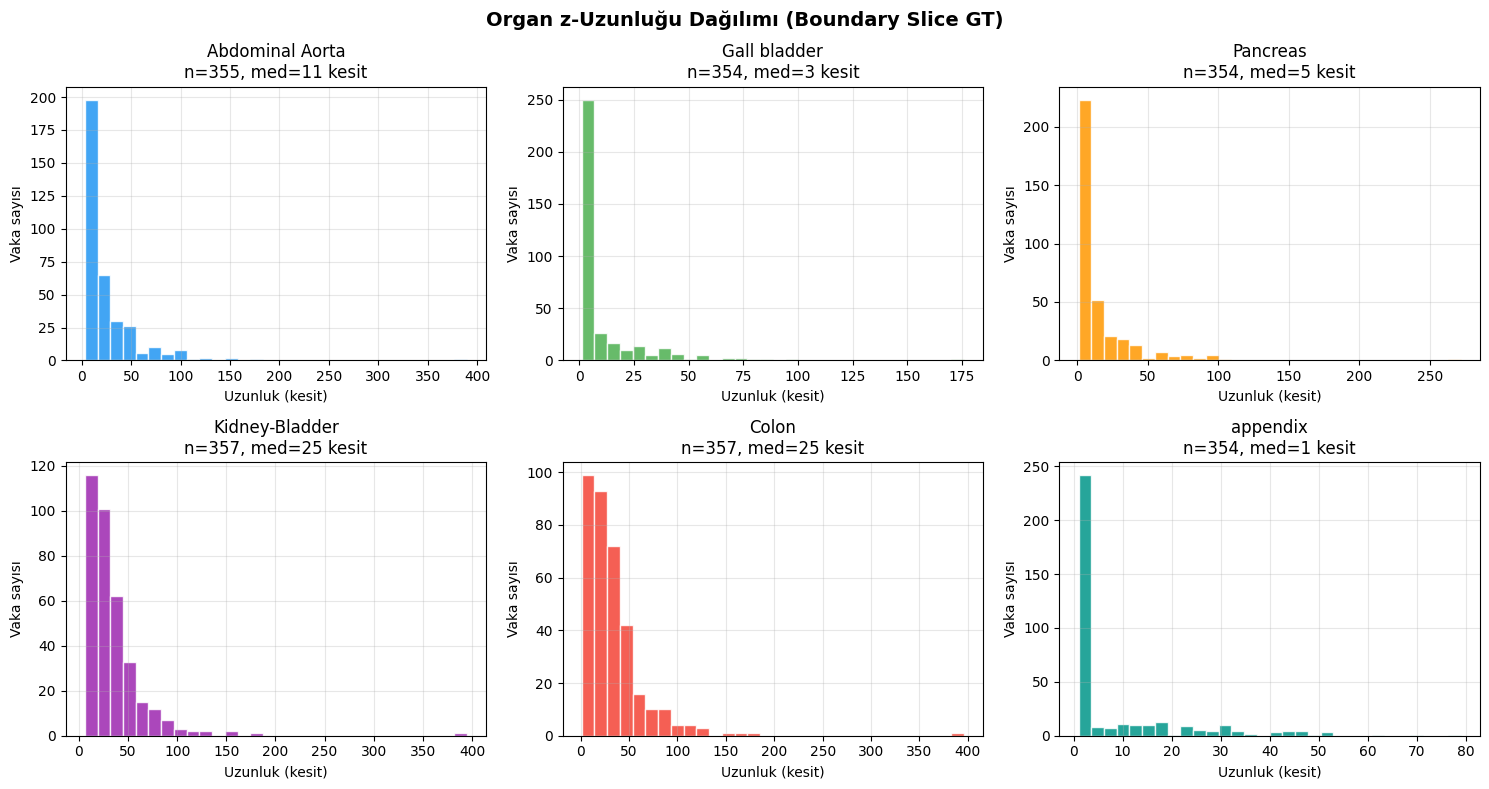

Kaydedildi: boundary_gt_distribution.png


In [3]:
# Organ uzunluklarının dağılımı (kesit cinsinden)
gt_df['length'] = gt_df['z_end'] - gt_df['z_start']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']

for i, organ in enumerate(OUR_ORGANS):
    sub = gt_df[gt_df['organ'] == organ]['length']
    if len(sub) == 0:
        axes[i].set_title(f'{organ}\n(annotasyon yok)')
        continue
    axes[i].hist(sub, bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{organ}\nn={len(sub)}, med={sub.median():.0f} kesit')
    axes[i].set_xlabel('Uzunluk (kesit)')
    axes[i].set_ylabel('Vaka sayısı')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Organ z-Uzunluğu Dağılımı (Boundary Slice GT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boundary_gt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: boundary_gt_distribution.png')

In [4]:
# Özet istatistik tablosu
summary = gt_df.groupby('organ')['length'].agg(['count','mean','median','min','max'])
summary.columns = ['n_vaka', 'ort_uzunluk', 'med_uzunluk', 'min', 'max']
summary = summary.round(1)
print('Boundary Slice GT Özet İstatistikleri (kesit cinsinden):')
print(summary.to_string())

Boundary Slice GT Özet İstatistikleri (kesit cinsinden):
                 n_vaka  ort_uzunluk  med_uzunluk  min  max
organ                                                      
Abdominal Aorta     355         24.4         11.0    3  390
Colon               357         33.7         25.0    1  396
Gall bladder        354         10.2          3.0    1  176
Kidney-Bladder      357         33.3         25.0    6  395
Pancreas            354         16.0          5.0    1  272
appendix            354          8.1          1.0    1   79


## 2 — TotalSegmentator Kurulum Kontrolü

In [5]:
import subprocess

# TotalSegmentator kurulu mu?
result = subprocess.run(['TotalSegmentator', '--help'], capture_output=True, text=True)
if result.returncode == 0:
    print('✅ TotalSegmentator kurulu ve çalışıyor.')
    # Versiyon bilgisi
    ver = subprocess.run(['TotalSegmentator', '--version'], capture_output=True, text=True)
    print('Versiyon:', ver.stdout.strip() or ver.stderr.strip())
else:
    print('❌ TotalSegmentator bulunamadı.')
    print('Kurulum: pip install TotalSegmentator')
    print()
    print('Kurulum sonrası model indirme (ilk çalıştırmada otomatik yapılır).')
    print('Tahmini boyut: ~2GB (fast model)')

✅ TotalSegmentator kurulu ve çalışıyor.
Versiyon: 2.5.0


In [ ]:
# SimpleITK kontrolü
try:
    import SimpleITK as sitk
    print('✅ SimpleITK:', sitk.Version_VersionString())
except ImportError:
    print('❌ SimpleITK kurulu değil → pip install SimpleITK')

# boundary_z_detect modülü
try:
    from src.boundary_z_detect import (
        predict_boundaries_zero_shot,
        _z_profile, _detect_interval,
        BoundaryCalibrator, evaluate,
        OUR_ORGANS, TS_ORGAN_MAP
    )
    print('✅ boundary_z_detect modülü yüklendi.')
    print(f'   Takip edilen organlar ({len(OUR_ORGANS)}):', OUR_ORGANS)
except Exception as e:
    print(f'❌ Modül yüklenemedi: {e}')

✅ SimpleITK: 2.5.3
✅ boundary_z_detect modülü yüklendi.
   Takip edilen organlar (6): ['Abdominal Aorta', 'Gall bladder', 'Pancreas', 'Kidney-Bladder', 'Colon', 'appendix']


## 3 — Tek Vaka: z-Profil Görselleştirme

TotalSegmentator çıktısı zaten varsa `ts_cache` dizininden okunur.  
Yoksa otomatik çalıştırılır (~2-5 dakika/vaka, fast mod).

In [7]:
# Test edilecek vakayı seç — val setindeki ilk vakaları listele
val_cases = pd.read_csv(SPLIT_DIR / 'fold0_val.csv')['Case Number'].tolist()
print(f'Validation seti: {len(val_cases)} vaka')
print('İlk 10:', val_cases[:10])

# GT annotasyonu olan vakalarla kesişim
gt_cases = set(gt_df['case'].tolist())
annotated_val = [c for c in val_cases if c in gt_cases]
print(f'GT boundary annotasyonlu val vakası: {len(annotated_val)}')

Validation seti: 111 vaka
İlk 10: [20115, 20181, 20081, 20073, 20442, 20503, 20222, 20498, 20350, 20388]
GT boundary annotasyonlu val vakası: 57


In [8]:
# İlk annotasyonlu vakayı seç ve TotalSegmentator çalıştır
# (önceden hesaplandıysa ts_cache'den okur, tekrar çalışmaz)

TEST_CASE_ID = annotated_val[0] if annotated_val else val_cases[0]
print(f'Test vakası: {TEST_CASE_ID}')

# Vaka dizinini bul (train veya test'te olabilir)
case_dir = None
for src in (TRAIN_DIR, TEST_DIR):
    candidate = src / str(TEST_CASE_ID)
    if candidate.exists():
        case_dir = candidate
        break

if case_dir is None:
    print(f'HATA: {TEST_CASE_ID} dizini bulunamadı.')
else:
    print(f'Dizin: {case_dir}')
    dcm_files = list(case_dir.glob('*.dcm'))
    print(f'DICOM kesit sayısı: {len(dcm_files)}')

Test vakası: 20115
Dizin: /Users/ramazanpolat/Desktop/datasets/abdomen/Eğitim Verisi/20115
DICOM kesit sayısı: 172


In [9]:
# TotalSegmentator çalıştır ve sınırları tespit et
# (Bu hücre TS kurulu değilse hata verir — kurulum sonrası çalıştırın)

if case_dir is not None:
    print(f'TotalSegmentator çalıştırılıyor (fast mod)...')
    print('İlk çalıştırmada model indiriliyor (~2GB), sonraki çalıştırmalar hızlı.')
    
    preds = predict_boundaries_zero_shot(
        case_dir,
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
        threshold=0.005,
        min_run=2,
    )
    
    print(f'\n--- Vaka {TEST_CASE_ID} Sınır Tespiti ---')
    #print(f'{'Organ':<25} {'z_start':>8} {'z_end':>8} {'uzunluk':>8}')
    print('-' * 55)
    for organ, iv in preds.items():
        if iv:
            print(f'{organ:<25} {iv[0]:>8} {iv[1]:>8} {iv[1]-iv[0]+1:>8}')
        else:
            print(f'{organ:<25} {"—":>8} {"—":>8} {"—":>8}')
    
    # GT ile karşılaştır
    gt_case = gt_df[gt_df['case'] == TEST_CASE_ID]
    if len(gt_case) > 0:
        print(f'\n--- GT Boundary Slice (Bilgi.xlsx) ---')
        for _, row in gt_case.iterrows():
            print(f'{row["organ"]:<25} {int(row["z_start"]):>8} {int(row["z_end"]):>8} {int(row["z_end"]-row["z_start"]+1):>8}')

TotalSegmentator çalıştırılıyor (fast mod)...
İlk çalıştırmada model indiriliyor (~2GB), sonraki çalıştırmalar hızlı.
No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Resampling...
  Resampled in 1.29s
Predicting...


100%|██████████| 4/4 [00:41<00:00, 10.31s/it]


  Predicted in 47.44s
Resampling...
Saving segmentations...
  Saved in 6.51s

--- Vaka 20115 Sınır Tespiti ---
-------------------------------------------------------
Abdominal Aorta                  —        —        —
Gall bladder                   137      142        6
Pancreas                       123      142       20
Kidney-Bladder                  95      143       49
Colon                           71      160       90
appendix                         —        —        —

--- GT Boundary Slice (Bilgi.xlsx) ---
Abdominal Aorta                 12       19        8
Colon                           16       24        9
Gall bladder                    15       18        4
Kidney-Bladder                  14       25       12
Pancreas                        13       17        5
appendix                        20       21        2


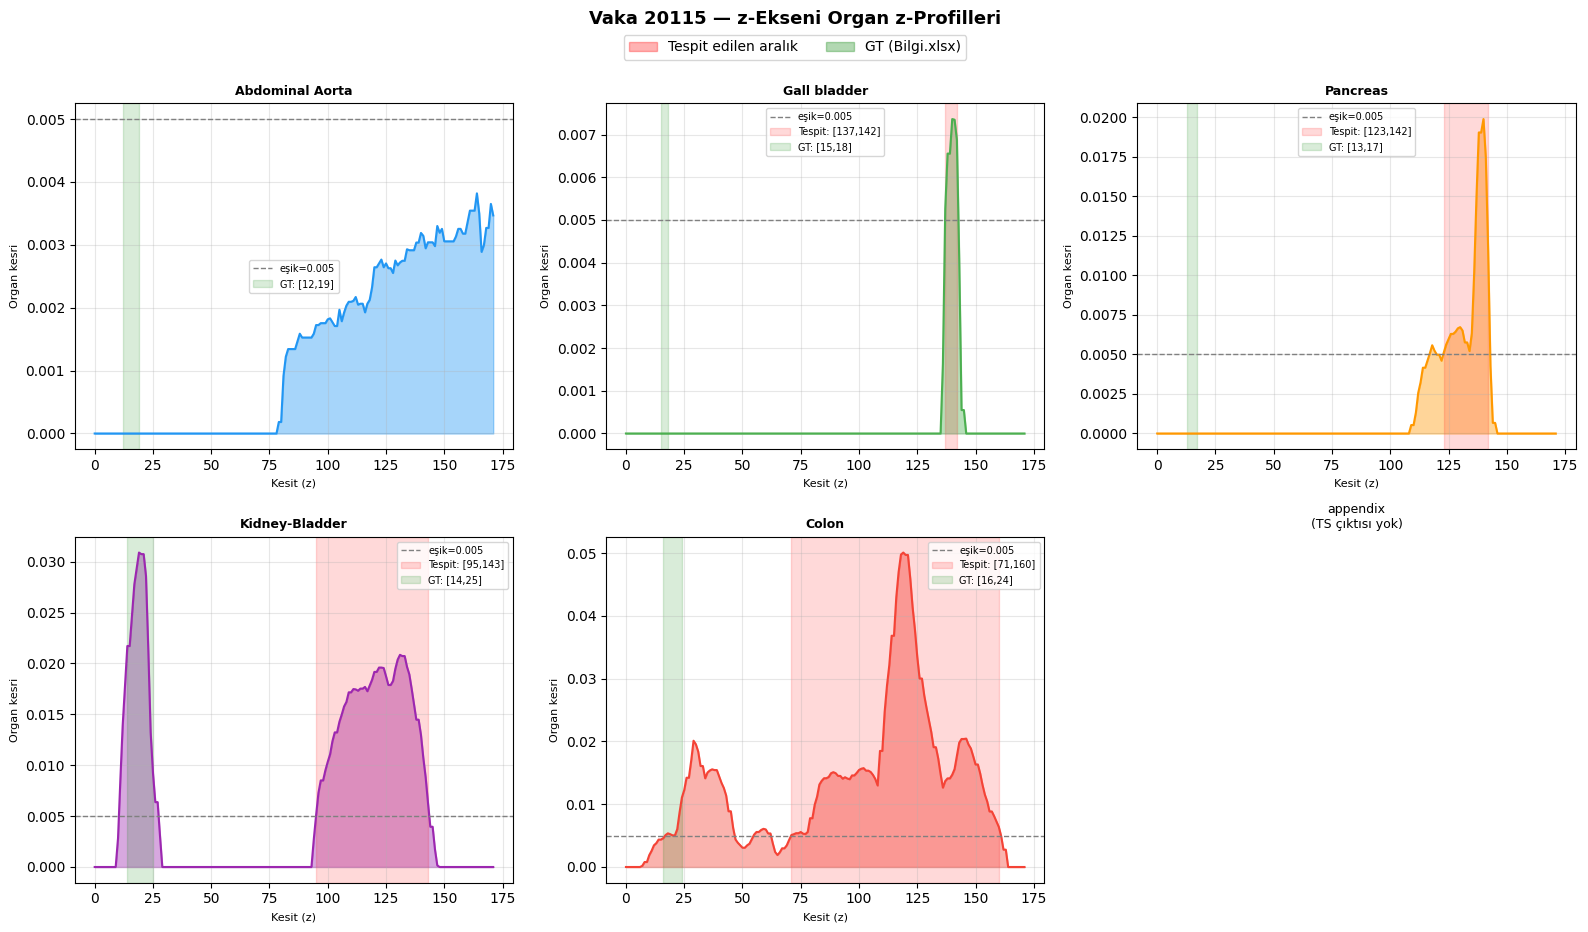

Kaydedildi: boundary_profile_case20115.png


In [10]:
# z-Profil görselleştirme
# (TS çıktısı ts_cache'de olmalı)

ts_out = TS_CACHE / str(TEST_CASE_ID)

if ts_out.exists() and any(ts_out.glob('*.nii.gz')):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']
    
    # Tüm sliceların sayısını referans için oku
    import SimpleITK as sitk
    nii_path = NII_CACHE / f'{TEST_CASE_ID}.nii.gz'
    if nii_path.exists():
        ref = sitk.ReadImage(str(nii_path))
        n_slices = sitk.GetArrayFromImage(ref).shape[0]
    else:
        n_slices = None
    
    for i, organ in enumerate(OUR_ORGANS):
        ax = axes[i]
        
        # Organ maskelerini birleştir
        combined_profile = None
        for ts_name, our_name in TS_ORGAN_MAP.items():
            if our_name != organ:
                continue
            mask_path = ts_out / f'{ts_name}.nii.gz'
            if not mask_path.exists():
                continue
            prof = _z_profile(mask_path)
            combined_profile = prof if combined_profile is None else np.maximum(combined_profile, prof)
        
        if combined_profile is None:
            ax.set_title(f'{organ}\n(TS çıktısı yok)', fontsize=9)
            ax.axis('off')
            continue
        
        z_vals = np.arange(len(combined_profile))
        ax.fill_between(z_vals, combined_profile, alpha=0.4, color=colors[i])
        ax.plot(z_vals, combined_profile, color=colors[i], lw=1.5)
        ax.axhline(0.005, color='gray', ls='--', lw=1, label='eşik=0.005')
        
        # Tespit edilen aralık
        interval = _detect_interval(combined_profile, threshold=0.005, min_run=2)
        if interval:
            ax.axvspan(interval[0], interval[1], alpha=0.15, color='red', label=f'Tespit: [{interval[0]},{interval[1]}]')
        
        # GT aralığı
        gt_row = gt_df[(gt_df['case'] == TEST_CASE_ID) & (gt_df['organ'] == organ)]
        if len(gt_row) > 0:
            z0, z1 = int(gt_row.iloc[0]['z_start']), int(gt_row.iloc[0]['z_end'])
            ax.axvspan(z0, z1, alpha=0.15, color='green', label=f'GT: [{z0},{z1}]')
        
        ax.set_title(f'{organ}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Kesit (z)', fontsize=8)
        ax.set_ylabel('Organ kesri', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    red_p = mpatches.Patch(color='red', alpha=0.3, label='Tespit edilen aralık')
    green_p = mpatches.Patch(color='green', alpha=0.3, label='GT (Bilgi.xlsx)')
    fig.legend(handles=[red_p, green_p], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))
    
    plt.suptitle(f'Vaka {TEST_CASE_ID} — z-Ekseni Organ z-Profilleri', fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'boundary_profile_case{TEST_CASE_ID}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Kaydedildi: boundary_profile_case{TEST_CASE_ID}.png')
else:
    print('TS çıktısı henüz yok. Önce TotalSegmentator çalıştırın.')

## 4 — Toplu Tahmin: Validation Seti

In [ ]:
# Validation setindeki tüm vakalar üzerinde çalıştır
# Not: Her vaka için TS ~2-5 dakika. İlk çalıştırmada ts_cache boş olduğundan uzun sürer.
# Sonraki çalıştırmalarda ts_cache'den okur, çok hızlıdır.

from src.boundary_z_detect import run_dataset
from tqdm import tqdm

val_case_dirs = []
for case_id in val_cases:
    for src in (TRAIN_DIR, TEST_DIR):
        candidate = src / str(case_id)
        if candidate.exists():
            val_case_dirs.append(candidate)
            break

print(f'Val dizini bulunan vaka sayısı: {len(val_case_dirs)} / {len(val_cases)}')

# Sadece GT annotasyonu olan vakalar (değerlendirme için)
val_gt_cases = [d for d in val_case_dirs if int(d.name) in gt_cases]
print(f'GT annotasyonlu: {len(val_gt_cases)} vaka')

Val dizini bulunan vaka sayısı: 111 / 111
GT annotasyonlu: 57 vaka


In [12]:
# Toplu tahmin — ts_cache'de olmayanlar için TS çalıştırılır
PRED_CSV = Path('boundary_preds_val.csv')

if PRED_CSV.exists():
    print(f'Mevcut tahmin dosyası okunuyor: {PRED_CSV}')
    pred_df = pd.read_csv(PRED_CSV)
else:
    pred_df = run_dataset(
        val_gt_cases,          # GT annotasyonlu vakalar
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
    )
    pred_df.to_csv(PRED_CSV, index=False)
    print(f'Kaydedildi: {PRED_CSV}')

print(f'Tahmin sayısı: {len(pred_df)} (vaka × organ)')
print()
print(pred_df.groupby('organ').size().sort_values(ascending=False).to_string())

Boundary Z-Detect:   2%|▏         | 1/57 [00:00<00:07,  7.95it/s]

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Resampling...
  Resampled in 2.22s
Predicting...


100%|██████████| 4/4 [00:39<00:00,  9.86s/it]


  Predicted in 45.20s
Resampling...
Saving segmentations...
  Saved in 9.09s


Boundary Z-Detect:   4%|▎         | 2/57 [01:07<36:26, 39.76s/it]

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Resampling...
  Resampled in 3.14s
Predicting...


100%|██████████| 8/8 [01:03<00:00,  7.92s/it]


  Predicted in 69.56s
Resampling...
Saving segmentations...
  Saved in 10.69s


Boundary Z-Detect: 100%|██████████| 57/57 [1:27:15<00:00, 91.86s/it]

Kaydedildi: boundary_preds_val.csv
Tahmin sayısı: 238 (vaka × organ)

organ
Colon              57
Kidney-Bladder     57
Pancreas           52
Abdominal Aorta    36
Gall bladder       36


## 5 — GT Karşılaştırması: MAE Değerlendirmesi

In [13]:
# Val seti GT'si (z-index cinsinden)
gt_val = build_gt_from_bilgi(BILGI, MANIFEST_CSV)
gt_val = gt_val[gt_val['case'].isin([int(d.name) for d in val_gt_cases])]

# Evaluate
result_df = evaluate(pred_df.to_dict('records'), gt_val)
print('=== Organ Sınır Tespiti — MAE (z-index = kesit cinsinden) ===')
print(result_df.to_string(index=False))

overall_mae = result_df[['mae_z_start','mae_z_end']].mean().mean()
print(f'\nGenel ortalama MAE: {overall_mae:.1f} kesit')
print()
print('Not: Kesit kalınlığı genellikle 2-5mm.')
print(f'  5 kesit hata  → ~10-25mm  (klinik olarak kabul edilebilir)')
print(f'  10 kesit hata → ~20-50mm  (iyileştirme gerekli)')

=== Organ Sınır Tespiti — MAE (z-index = kesit cinsinden) ===
          organ  n  mae_z_start  mae_z_end  mae_length
          Colon 57         56.6      119.8        69.9
 Kidney-Bladder 57         99.8      118.4        30.6
   Gall bladder 36        118.9      124.7        16.2
       Pancreas 52        134.3      134.6        16.2
Abdominal Aorta 36        197.6      191.1        21.9

Genel ortalama MAE: 129.6 kesit

Not: Kesit kalınlığı genellikle 2-5mm.
  5 kesit hata  → ~10-25mm  (klinik olarak kabul edilebilir)
  10 kesit hata → ~20-50mm  (iyileştirme gerekli)


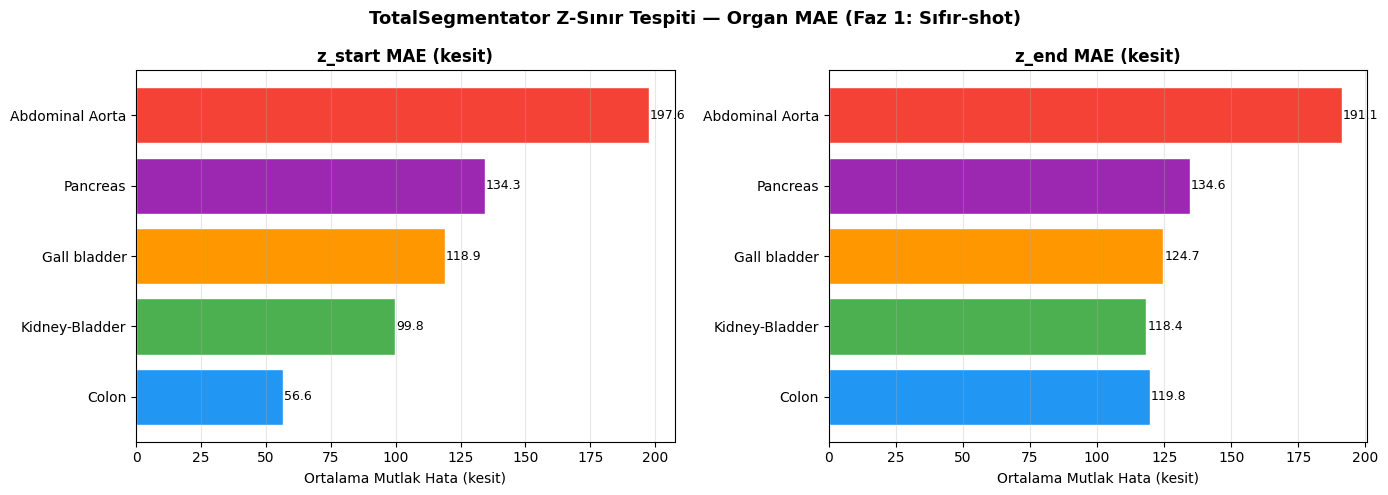

Kaydedildi: boundary_mae_results.png


In [14]:
# Organ bazlı MAE bar grafik
if len(result_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_bar = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']

    # z_start MAE
    axes[0].barh(result_df['organ'], result_df['mae_z_start'],
                 color=colors_bar[:len(result_df)], edgecolor='white')
    axes[0].set_title('z_start MAE (kesit)', fontweight='bold')
    axes[0].set_xlabel('Ortalama Mutlak Hata (kesit)')
    axes[0].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(result_df['mae_z_start']):
        axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

    # z_end MAE
    axes[1].barh(result_df['organ'], result_df['mae_z_end'],
                 color=colors_bar[:len(result_df)], edgecolor='white')
    axes[1].set_title('z_end MAE (kesit)', fontweight='bold')
    axes[1].set_xlabel('Ortalama Mutlak Hata (kesit)')
    axes[1].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(result_df['mae_z_end']):
        axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

    plt.suptitle('TotalSegmentator Z-Sınır Tespiti — Organ MAE (Faz 1: Sıfır-shot)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boundary_mae_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Kaydedildi: boundary_mae_results.png')

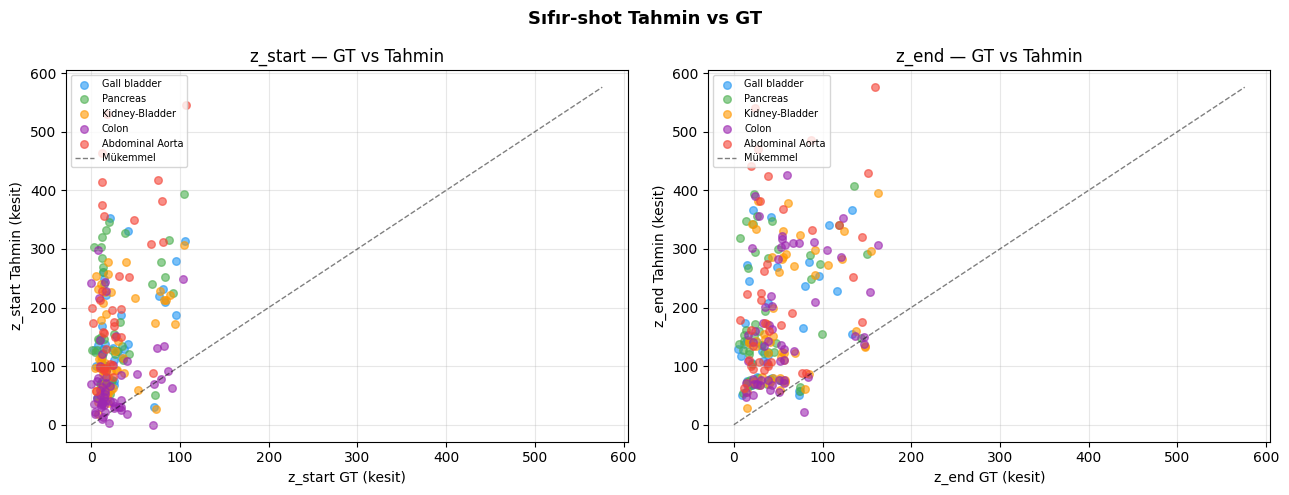

In [15]:
# Scatter plot: tahmin vs gerçek z_start (tüm organlar birlikte)
merged = pd.merge(
    pred_df, gt_val,
    on=['case','organ'], suffixes=('_pred','_gt')
)

if len(merged) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    organ_list = merged['organ'].unique()
    color_map = {o: c for o, c in zip(organ_list, ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688'])}

    for organ in organ_list:
        sub = merged[merged['organ'] == organ]
        c = color_map[organ]
        axes[0].scatter(sub['z_start_gt'], sub['z_start_pred'], label=organ, color=c, alpha=0.6, s=30)
        axes[1].scatter(sub['z_end_gt'],   sub['z_end_pred'],   label=organ, color=c, alpha=0.6, s=30)

    max_val = merged[['z_start_gt','z_start_pred','z_end_gt','z_end_pred']].max().max()
    for ax, title in zip(axes, ['z_start', 'z_end']):
        ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5, label='Mükemmel')
        ax.set_xlabel(f'{title} GT (kesit)')
        ax.set_ylabel(f'{title} Tahmin (kesit)')
        ax.set_title(f'{title} — GT vs Tahmin')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Sıfır-shot Tahmin vs GT', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boundary_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6 — Faz 2: Eşik Kalibrasyonu (BoundaryCalibrator)

In [ ]:
# Kalibrasyon için train setindeki z-profillerini oku
# (ts_cache'de TotalSegmentator çıktıları olmalı)

train_cases_ids = pd.read_csv(SPLIT_DIR / 'fold0_train.csv')['Case Number'].tolist()
gt_train = build_gt_from_bilgi(BILGI, MANIFEST_CSV)
gt_train = gt_train[gt_train['case'].isin(train_cases_ids)]
print(f'Eğitim seti GT annotasyonu: {len(gt_train)} satır')
print('Sütunlar:', gt_train.columns.tolist())
print()
print('Örnek (Image Id ve z-index yan yana):')
print(gt_train.head(6).to_string(index=False))

# z-profillerini ts_cache'den yükle
from src.boundary_z_detect import _z_profile, TS_ORGAN_MAP

train_profiles = {organ: [] for organ in OUR_ORGANS}
train_gt_list  = {organ: [] for organ in OUR_ORGANS}

available_train = [c for c in train_cases_ids if (TS_CACHE / str(c)).exists()]
print(f"\nts_cache'de mevcut train vakası: {len(available_train)} / {len(train_cases_ids)}")

for case_id in available_train:
    ts_out = TS_CACHE / str(case_id)
    organ_profs = {}
    for ts_name, our_name in TS_ORGAN_MAP.items():
        mask_path = ts_out / f'{ts_name}.nii.gz'
        if not mask_path.exists():
            continue
        prof = _z_profile(mask_path)
        if our_name not in organ_profs:
            organ_profs[our_name] = prof
        else:
            organ_profs[our_name] = np.maximum(organ_profs[our_name], prof)

    gt_case = gt_train[gt_train['case'] == case_id]
    for organ in OUR_ORGANS:
        gt_row = gt_case[gt_case['organ'] == organ]
        gt_val_entry = None
        if len(gt_row) > 0:
            # z_start / z_end artık gerçek z-index (manifest'ten dönüştürülmüş)
            gt_val_entry = (int(gt_row.iloc[0]['z_start']), int(gt_row.iloc[0]['z_end']))
        if organ in organ_profs:
            train_profiles[organ].append(organ_profs[organ])
            train_gt_list[organ].append(gt_val_entry)

print('Profil yükleme tamamlandı.')

Eğitim seti GT annotasyonu: 1369 satır
Sütunlar: ['case', 'organ', 'img_id_start', 'img_id_end', 'z_start', 'z_end']

Örnek (Image Id ve z-index yan yana):
 case           organ  img_id_start  img_id_end  z_start  z_end
20001 Abdominal Aorta        100017      100047        4     10
20001           Colon        100014      100075        3     20
20001    Gall bladder        100019      100029        6      8
20001  Kidney-Bladder        100021      100091        7     22
20001        Pancreas        100018      100039        5      9
20001        appendix        100058      100079       11     21

ts_cache'de mevcut train vakası: 0 / 443
Profil yükleme tamamlandı.


In [17]:
# Kalibratörü eğit
CAL_PATH = 'boundary_calibrator.json'

if any(len(v) > 0 for v in train_profiles.values()):
    cal = BoundaryCalibrator()
    print('Eşik kalibrasyonu başlıyor...')
    cal.fit(train_profiles, train_gt_list)
    cal.save(CAL_PATH)
    print(f'\nKalibratör kaydedildi: {CAL_PATH}')
    print('\nKalibre edilmiş eşikler:')
    for organ in OUR_ORGANS:
        print(f'  {organ:<25} thr={cal.thresholds[organ]:.3f}, min_run={cal.min_runs[organ]}')
else:
    print('ts_cache boş — önce TotalSegmentator ile train vakalarını işleyin.')
    print('Kalibrasyon atlanıyor.')
    cal = None

ts_cache boş — önce TotalSegmentator ile train vakalarını işleyin.
Kalibrasyon atlanıyor.


In [18]:
# Kalibre edilmiş tahminlerle değerlendirme
if cal is not None:
    pred_df_cal = run_dataset(
        val_gt_cases,
        ts_cache_dir=TS_CACHE,
        nii_cache_dir=NII_CACHE,
        calibrator=cal,
    )
    pred_df_cal.to_csv('boundary_preds_val_calibrated.csv', index=False)
    
    result_cal = evaluate(pred_df_cal.to_dict('records'), gt_val)
    
    print('=== Faz 1 (Sıfır-shot) vs Faz 2 (Kalibre) Karşılaştırması ===')
    print(f'\n{"Organ":<25} {"z_start MAE":>12} {"":>5} {"z_start MAE":>12}')
    print(f'{"":<25} {"Faz-1":>12} {"→":>5} {"Faz-2":>12}')
    print('-' * 60)
    
    for _, row_f1 in result_df.iterrows():
        organ = row_f1['organ']
        row_f2 = result_cal[result_cal['organ'] == organ]
        if len(row_f2) == 0:
            continue
        f2_mae = row_f2.iloc[0]['mae_z_start']
        delta = f2_mae - row_f1['mae_z_start']
        arrow = '↓' if delta < 0 else ('↑' if delta > 0 else '=')
        print(f'{organ:<25} {row_f1["mae_z_start"]:>12.1f} {arrow:>5} {f2_mae:>12.1f}')

## 7 — Özet: Faz 1 vs Faz 2 vs YOLO Karşılaştırması

In [19]:
# Sonuç özeti tablosu
print('=' * 70)
print('ÖZET: TotalSegmentator Z-Sınır Tespiti')
print('=' * 70)
print()
print('Yöntem karşılaştırması:')
print(f'  Faz 1 (sıfır-shot):      Eğitim gerektirmez, TS çıktısı + eşikleme')
print(f'  Faz 2 (kalibre):         Boundary Slice GT ile eşik optimizasyonu')
print()

if len(result_df) > 0:
    print('Faz 1 Sonuçları:')
    print(result_df[['organ','n','mae_z_start','mae_z_end','mae_length']].to_string(index=False))
    overall = result_df[['mae_z_start','mae_z_end']].mean().mean()
    print(f'\nGenel ortalama MAE: {overall:.1f} kesit')
    
print()
print('Not: CT slice thickness genellikle 2-5mm.')
print('  5 kesit hata → ~10-25mm — klinik olarak kabul edilebilir sınır.')
print('  10 kesit hata → ~20-50mm — iyileştirme gerekli.')

ÖZET: TotalSegmentator Z-Sınır Tespiti

Yöntem karşılaştırması:
  Faz 1 (sıfır-shot):      Eğitim gerektirmez, TS çıktısı + eşikleme
  Faz 2 (kalibre):         Boundary Slice GT ile eşik optimizasyonu

Faz 1 Sonuçları:
          organ  n  mae_z_start  mae_z_end  mae_length
          Colon 57         56.6      119.8        69.9
 Kidney-Bladder 57         99.8      118.4        30.6
   Gall bladder 36        118.9      124.7        16.2
       Pancreas 52        134.3      134.6        16.2
Abdominal Aorta 36        197.6      191.1        21.9

Genel ortalama MAE: 129.6 kesit

Not: CT slice thickness genellikle 2-5mm.
  5 kesit hata → ~10-25mm — klinik olarak kabul edilebilir sınır.
  10 kesit hata → ~20-50mm — iyileştirme gerekli.


In [20]:
# Üretilen dosyaları listele
import glob
outputs = glob.glob('boundary_*.png') + glob.glob('boundary_*.csv') + glob.glob('boundary_*.json')
print('Üretilen çıktılar:')
for f in sorted(outputs):
    size = Path(f).stat().st_size
    print(f'  {f}  ({size/1024:.1f} KB)')

Üretilen çıktılar:
  boundary_gt_distribution.png  (113.1 KB)
  boundary_mae_results.png  (54.2 KB)
  boundary_preds_val.csv  (5.7 KB)
  boundary_profile_case20115.png  (208.7 KB)
  boundary_scatter.png  (174.3 KB)
